# Relatório Final — Agente Imobiliário Multiagente (FIAP)

Este notebook documenta a **arquitetura**, o **funcionamento** e evidências do sistema desenvolvido para o Projeto Final.

**Stack:** LangGraph + LangChain · Ollama (`llama3.1:8b` / HF Meta-Llama-3.1-8B-Instruct) · ChromaDB · Streamlit · SQLite

## 1. Objetivo

Demonstrar um ecossistema multiagente capaz de:
- Atender leads com especialistas (busca, avaliação, jurídico, financiamento, vendas, CRM)
- Aprimorar respostas com **RAG** seedado
- Catalogar origem e preferências do lead
- Reengajar leads inativos
- Agendar visitas com e-mail/ICS
- Emitir relatórios gerenciais do funil

## 2. Arquitetura

```
Us (Streamlit)
    → Supervisor (roteia intenção)
        → Busca / Avaliação / Jurídico / Financiamento / Vendas / CRM / Agendamento
            → RAG (Chroma) + Tools (SQLite catálogo/CRM/agenda)
        → Síntese → resposta final
```

Insira aqui o diagrama exportado ou prints em `../assets/screenshots/`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import OLLAMA_MODEL, CHROMA_DIR, DB_PATH
from src.db.models import init_db
from src.db import repository as repo

init_db()
print("Modelo:", OLLAMA_MODEL)
print("DB:", DB_PATH)
print("Chroma:", CHROMA_DIR)

Modelo: llama3.1-hf
DB: C:\Users\stefa\Documents\Cursos\FIAP Pós\Hackaton_Agente_Imobiliario\data\app.db
Chroma: C:\Users\stefa\Documents\Cursos\FIAP Pós\Hackaton_Agente_Imobiliario\data\chroma


## 3. Catálogo seedado (100 imóveis)

In [2]:
resid = repo.list_properties(segmento="residencial", limit=100)
empres = repo.list_properties(segmento="empresarial", limit=100)
print(f"Residenciais: {len(resid)}")
print(f"Empresariais: {len(empres)}")
print("Exemplo residencial:", repo.property_to_dict(resid[0])["titulo"] if resid else None)
print("Exemplo empresarial:", repo.property_to_dict(empres[0])["titulo"] if empres else None)

Residenciais: 50
Empresariais: 50
Exemplo residencial: Kitnet em Moema
Exemplo empresarial: Sala Comercial em Diadema Centro


## 4. Funil de leads e origens

In [3]:
print("Funil:", repo.funnel_counts())
print("Origens:", repo.origem_distribution())
print("Top bairros:", repo.top_bairros_buscados())
inativos = repo.inactive_leads_for_reengagement()
print(f"Leads elegíveis a reengajamento: {len(inativos)} →", [l.id for l in inativos])

Funil: {'novo': 3, 'interessado': 7, 'negociacao': 2, 'comprado': 1, 'finalizado': 1, 'total': 14}
Origens: {'direto': 4, 'google': 3, 'indicacao': 2, 'quinto_andar': 3, 'zap': 2}
Top bairros: [('Brooklin', 2), ('Itaim Bibi', 2), ('Perdizes', 2), ('Santana', 2), ('Tatuapé', 2)]
Leads elegíveis a reengajamento: 3 → ['LEAD-010', 'LEAD-011', 'LEAD-012']


## 5. RAG — recuperação de contexto

Requer Ollama com `nomic-embed-text` e índice criado via `scripts/seed_and_ingest.py`.

In [4]:
try:
    from src.rag.retriever import retrieve, format_context
    docs = retrieve("documentação para compra de imóvel ITBI", k=3)
    print(format_context(docs))
except Exception as e:
    print("RAG indisponível (rode o seed com Ollama):", e)

[1] Checklist documentação compra e venda (score=0.0328, hybrid_rrf)
Checklist documentação compra e venda

Documentos fictícios usuais: RG/CPF comprador e vendedor, matrícula atualizada, certidões negativas, IPTU quitado, declaração de quitação de condomínio. Escritura em cartório e registro na matrícula concluem a transferência.

---

[2] FAQ ITBI e registro (score=0.0318, hybrid_rrf)
FAQ ITBI e registro

ITBI é tributo municipal sobre transmissão onerosa. Alíquota fictícia típica em SP é discutida em percentuais locais. O registro no Cartório de Imóveis é o que transfere a propriedade perante terceiros.

---

[3] Panorama de mercado — Itaim Bibi (score=0.0298, hybrid_rrf)
Panorama de mercado — Itaim Bibi

O bairro Itaim Bibi em São Paulo apresenta demanda estável por imóveis residenciais de 2 e 3 dormitórios. Preços médios fictícios variam conforme proximidade ao metrô. Para o segmento empresarial, salas comerciais de 40–80 m² têm boa liquidez. Investidores devem observar vacância e

## 6. Execução ponta a ponta do grafo (exemplo)

Requer Ollama com `llama3.1:8b`. Sem o modelo, o sistema usa fallbacks heurísticos onde possível.

In [5]:
from src.graph.workflow import run_agent

lead_id = "LEAD-001"
try:
    result = run_agent(
        "Quero um apartamento em Moema até R$ 900000",
        lead_id=lead_id,
    )
    print("Intent:", result.get("intent"))
    print("Rota:", result.get("route"))
    print("\nResposta final:\n", result.get("final_response"))
    print("\nImóveis:", [p["id"] for p in (result.get("properties_found") or [])])
except Exception as e:
    print("Falha ao executar grafo:", e)

Intent: busca
Rota: ['busca', 'crm', 'sintese']

Resposta final:
 Olá! Estou aqui para ajudá-lo a encontrar um imóvel em Moema que atenda aos seus requisitos.

Infelizmente, não há imóveis disponíveis que atendam aos seus requisitos de preço (até R$ 900.000,00) e tipo de imóvel (apartamento). No entanto, posso sugerir algumas opções que podem ser interessantes:

1. **Apartamento em Moema (RES-001)**: Embora seja um pouco acima do seu orçamento, este apartamento é uma opção interessante. Ele tem 4 quartos, 2 vagas de garagem e comodidades como academia, elevador e piscina. O preço é de R$ 1.160.432,00.
2. **Kitnet em Moema (RES-020)**: Este kitnet é uma opção mais acessível, com preço de R$ 578.070,00. Ele tem 1 quarto e não oferece vagas de garagem. No entanto, ele tem comodidades como playground, academia e elevador.

Se você estiver disposto a considerar opções fora do seu orçamento inicial, posso sugerir algumas outras opções:

1. **Loja em Moema (COM-038)**: Embora seja uma loja, e

## 7. Simulação de financiamento e agendamento (tools)

In [6]:
from src.tools.mortgage_simulator import simulate_mortgage, format_simulation
from src.tools.scheduling import schedule_visit_or_consult
from datetime import datetime, timedelta

sim = simulate_mortgage(850_000, entrada_percent=20, prazo_meses=240)
print(format_simulation(sim))

inicio = (datetime.utcnow() + timedelta(days=2)).replace(hour=14, minute=0, second=0, microsecond=0)
appt = schedule_visit_or_consult(
    lead_id="LEAD-002",
    seller_id="SEL-001",
    inicio_iso=inicio.isoformat(),
    tipo="visita",
    property_id="RES-001",
    send_email=True,
)
print("\nAgendamento:", appt)

Valor do imóvel: R$ 850,000.00
Entrada (20%): R$ 170,000.00
Financiado: R$ 680,000.00
Prazo: 240 meses | Taxa a.a.: 10.5%
Parcela estimada (PRICE): R$ 6,788.98
Obs.: Regras fictícias para simulação acadêmica. Não representam oferta bancária real. Parcela estimada pelo sistema Price: PMT = PV * i*(1+i)^n / ((1+i)^n - 1).

Agendamento: {'ok': True, 'appointment_id': 'APT-65B2D8B6', 'titulo': 'Visita — lead LEAD-002 | imóvel RES-001', 'inicio': '2026-09-27T14:00:00', 'fim': '2026-09-27T15:00:00', 'email': {'ok': True, 'mode': 'mock', 'to': 'maria.oliveira@email.com', 'eml': 'C:\\Users\\stefa\\Documents\\Cursos\\FIAP Pós\\Hackaton_Agente_Imobiliario\\data\\outbox\\APT-65B2D8B6.eml', 'ics': 'C:\\Users\\stefa\\Documents\\Cursos\\FIAP Pós\\Hackaton_Agente_Imobiliario\\data\\outbox\\APT-65B2D8B6.ics'}}


C:\Users\stefa\AppData\Local\Temp\ipykernel_6116\1868089305.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  inicio = (datetime.utcnow() + timedelta(days=2)).replace(hour=14, minute=0, second=0, microsecond=0)


## 8. Relatório gerencial (métricas + narrativa)

In [7]:
from src.services.reports import build_report

report = build_report(periodo="mes", with_narrative=True)
for k in ["leads_gerados", "leads_interessados", "leads_negociacao", "leads_comprados_pos_venda"]:
    print(f"{k}: {report[k]}")
print("\nNarrativa:\n", report.get("narrative"))

leads_gerados: 14
leads_interessados: 8
leads_negociacao: 2
leads_comprados_pos_venda: 1

Narrativa:
 **Resumo do Relatório**

O relatório apresenta os resultados do período de 1 a 30 de setembro de 2026. Durante esse período, foram gerados 14 leads, sendo 8 interessados e 2 em negociação. Além disso, 1 lead foi comprado após a venda e 2 novos leads foram gerados. Os agendamentos também foram monitorados, com 7 agendados, 3 realizados, 3 no show e 0 cancelados.

**Insights Úteis para Gestores**

* **Taxa de Conversão**: A taxa de conversão de interessados para negociação é de 25,0%, o que é um indicador positivo. No entanto, a taxa de conversão de negociação para compra é de 50,0%, o que é um indicador ainda mais positivo.
* **Bairros Mais Populares**: Os bairros mais populares para buscas e imóveis são Brooklin, Itaim Bibi, Perdizes, Santana e Tatuapé, com cada um deles tendo 2 buscas e 2 imóveis.
* **Preços Médios**: Os preços médios dos imóveis nos bairros mais populares variam de R

## 9. Prints da interface (entrega)

Cole/exiba imagens de `../assets/screenshots/`:
- Chat com painel de agentes/RAG
- Catálogo residencial e empresarial
- Detalhe do imóvel com galeria
- CRM de leads
- Calendário
- Relatório gerencial
- Arquivo `.ics` / `.eml` em `data/outbox/`

02_chat_agentes.png


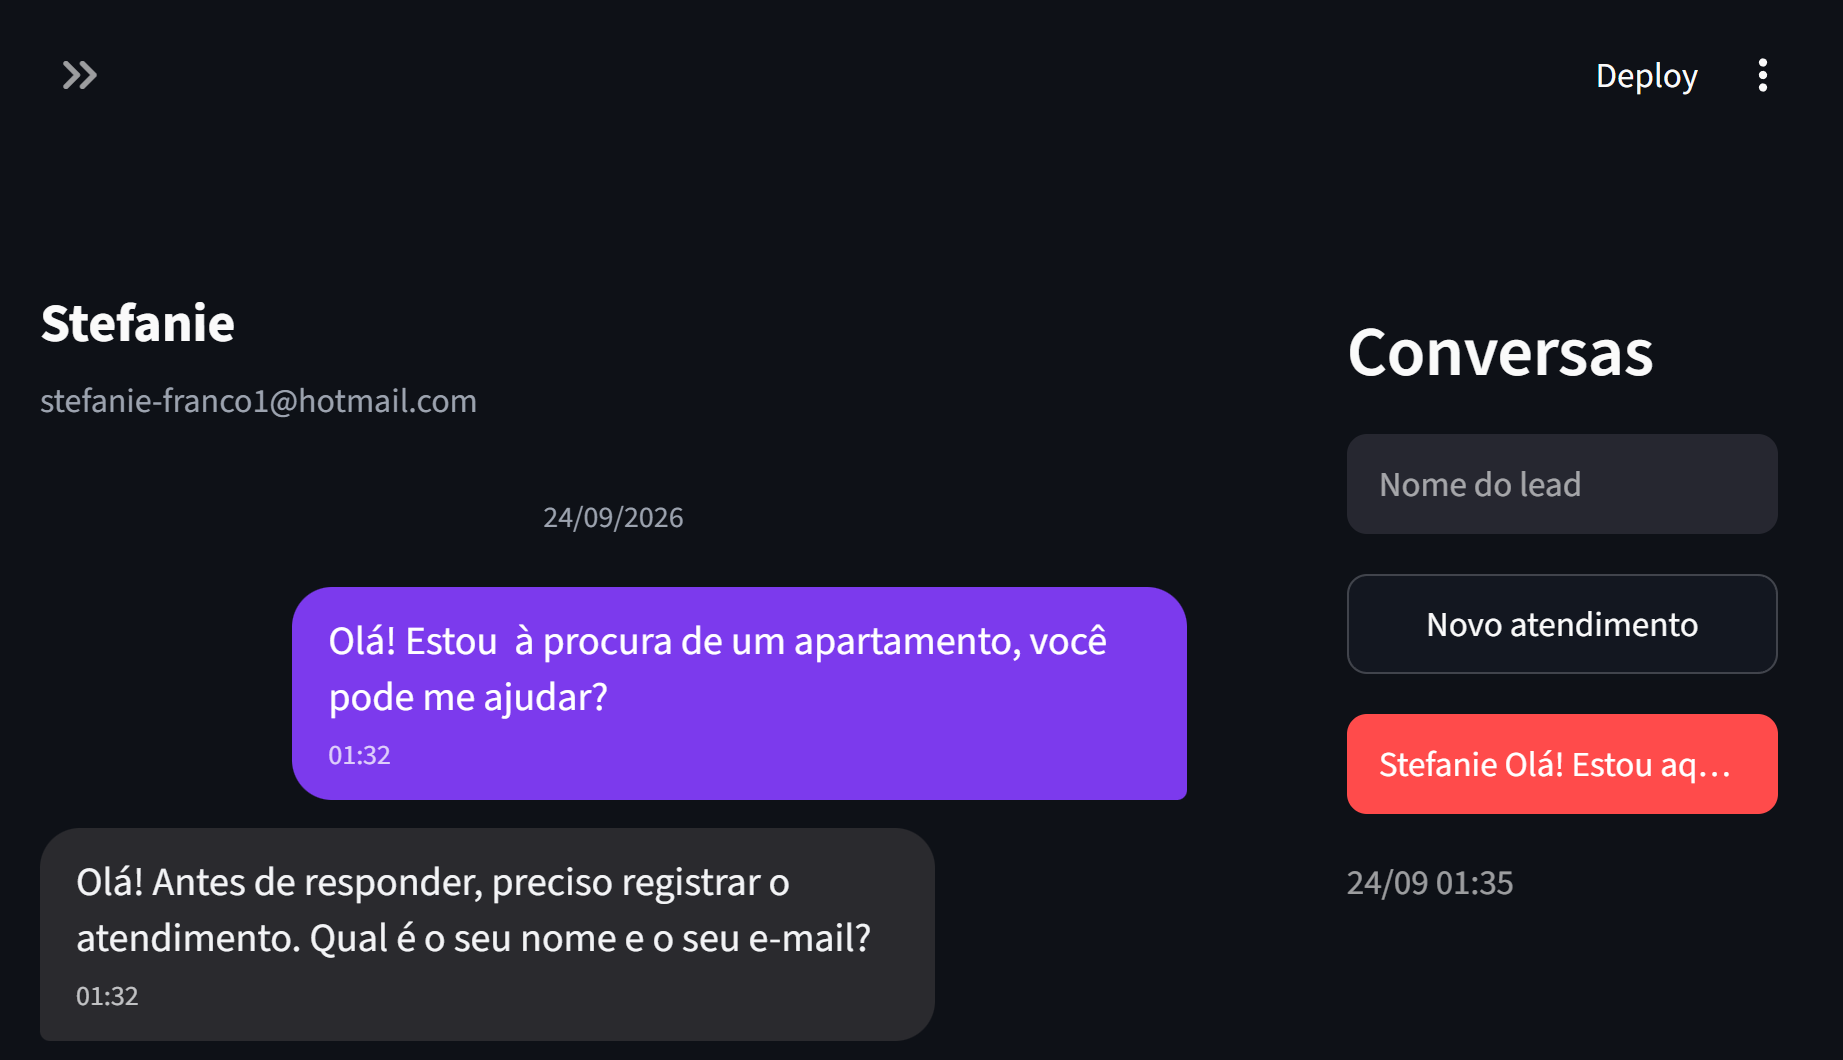

03_catalogo.png


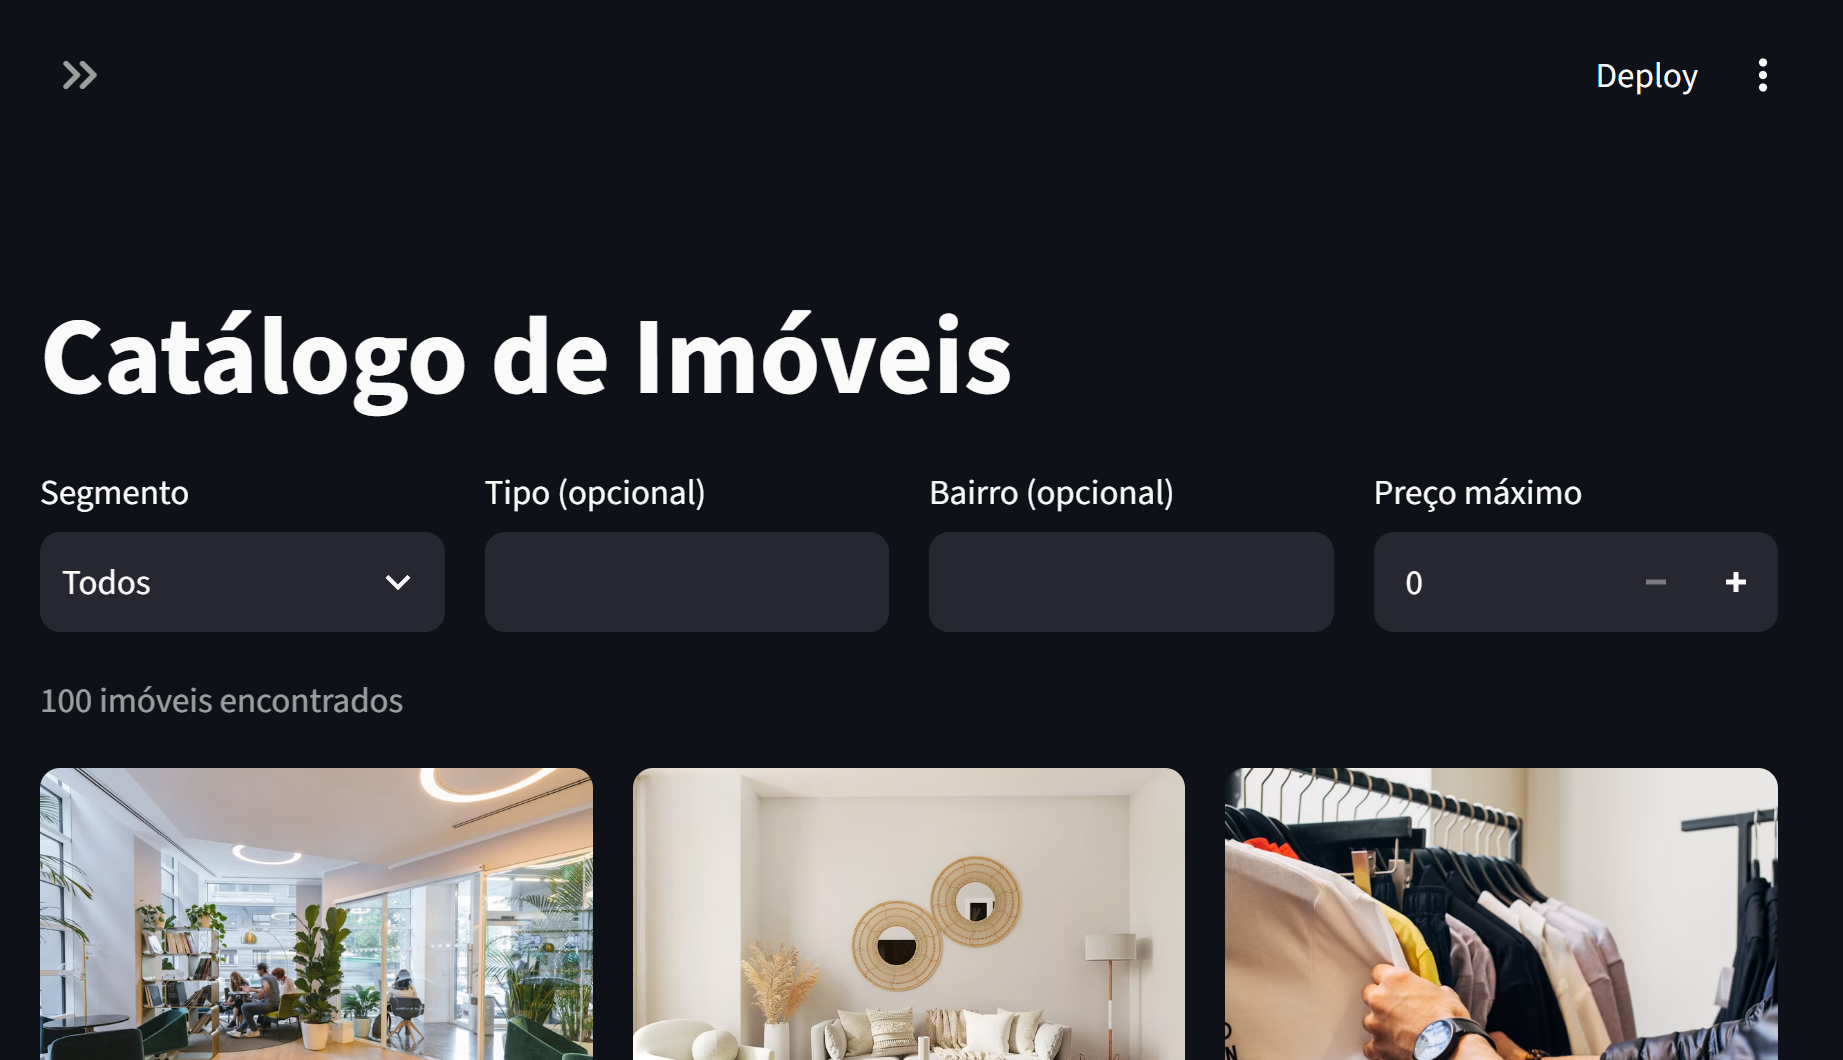

04_detalhe_imovel.png


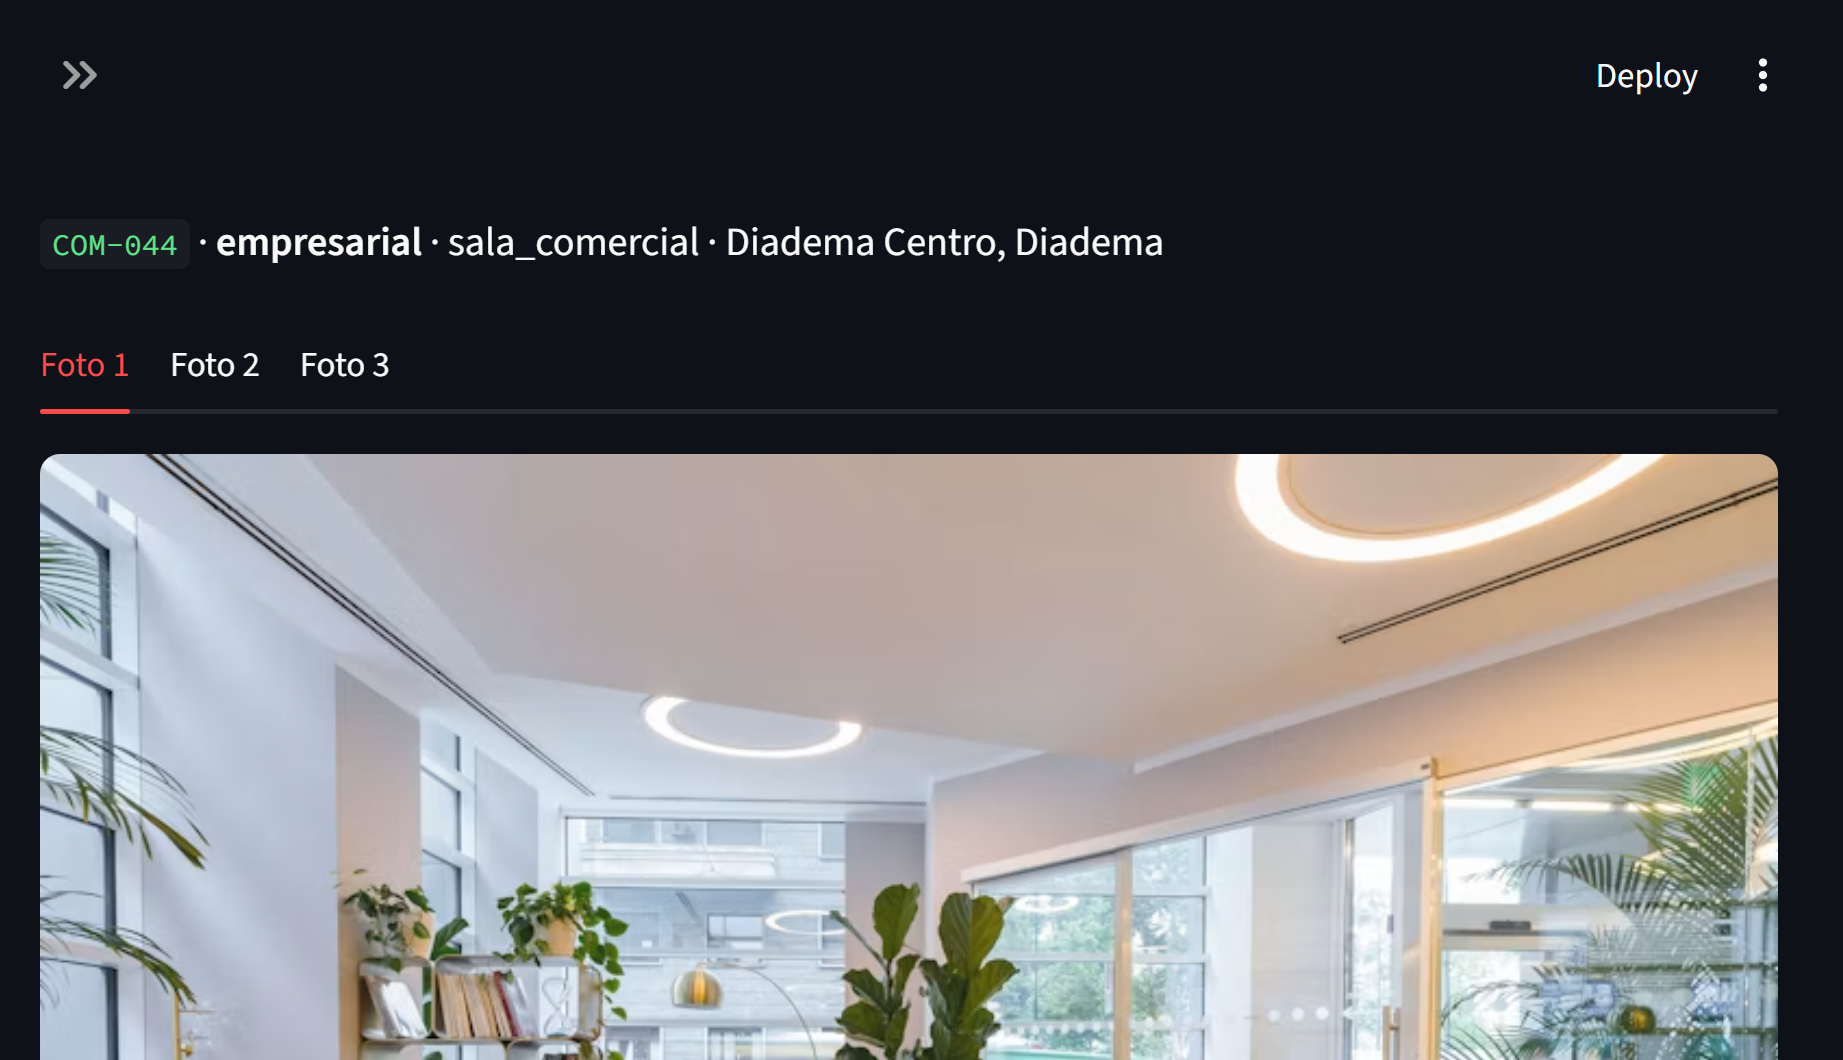

05_leads_crm.png


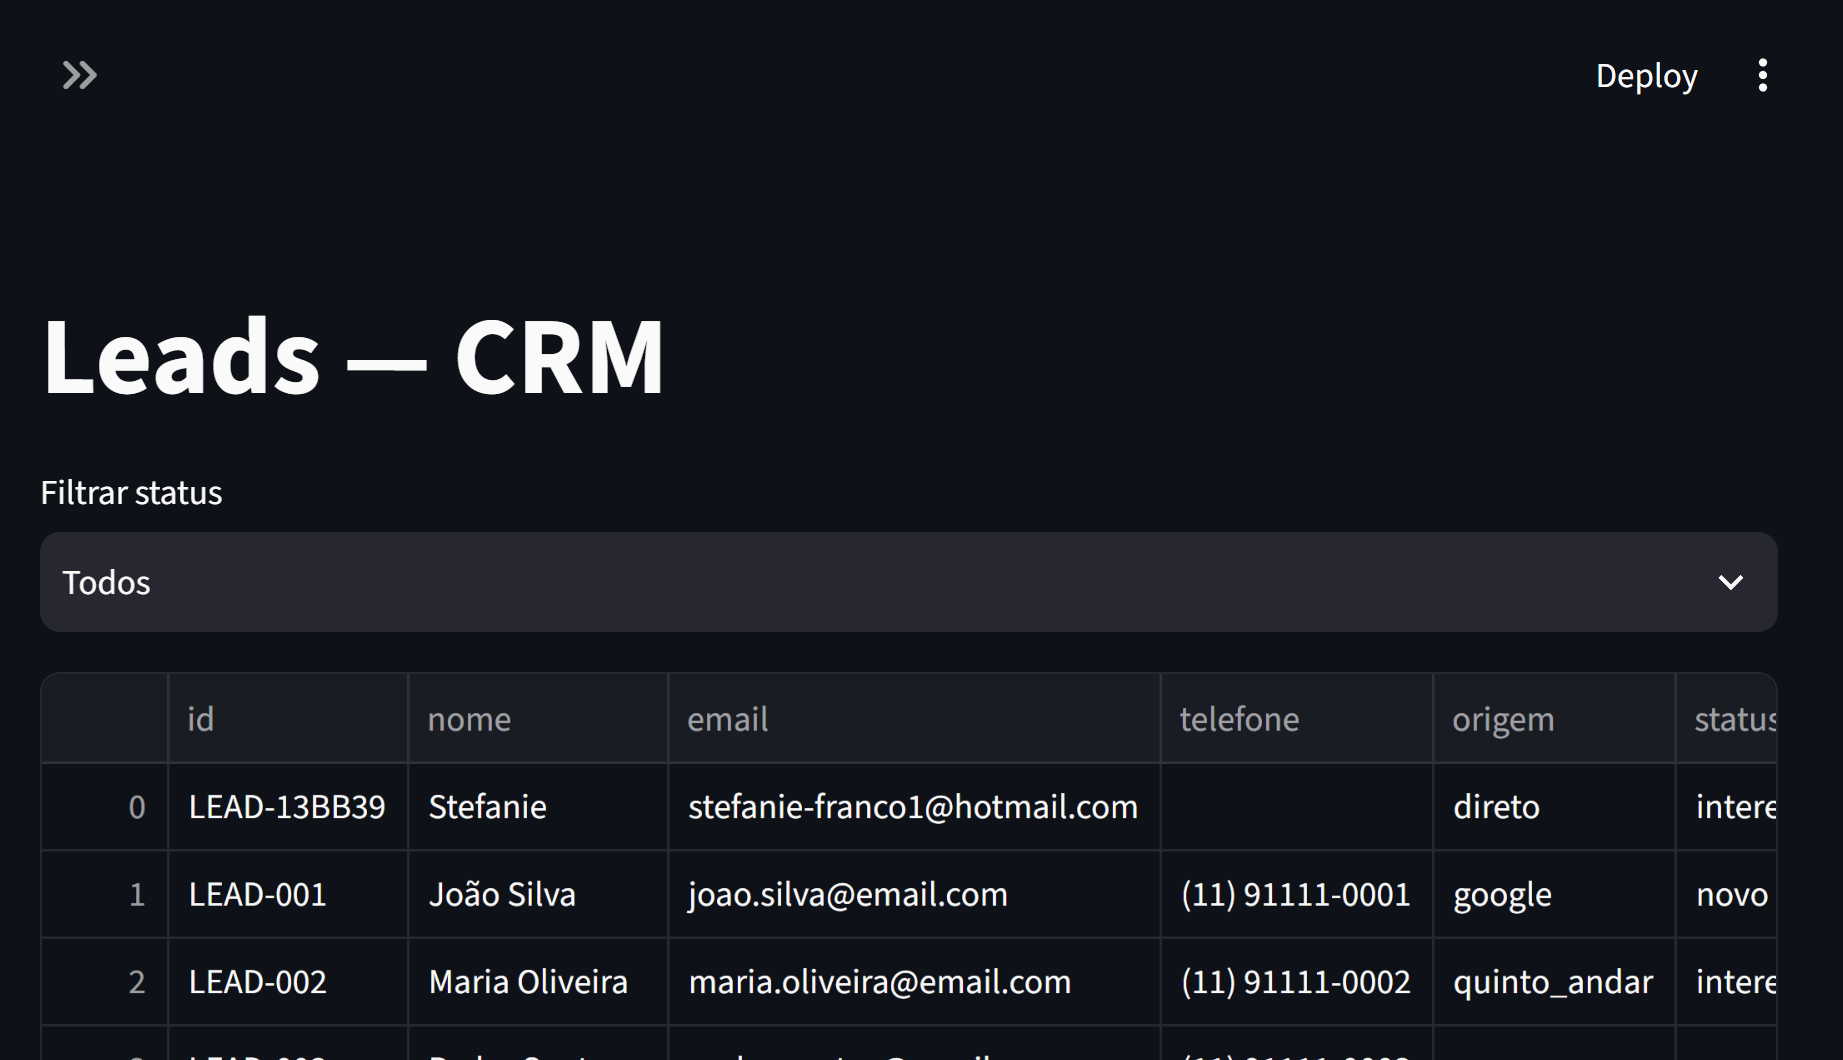

06_calendario.png


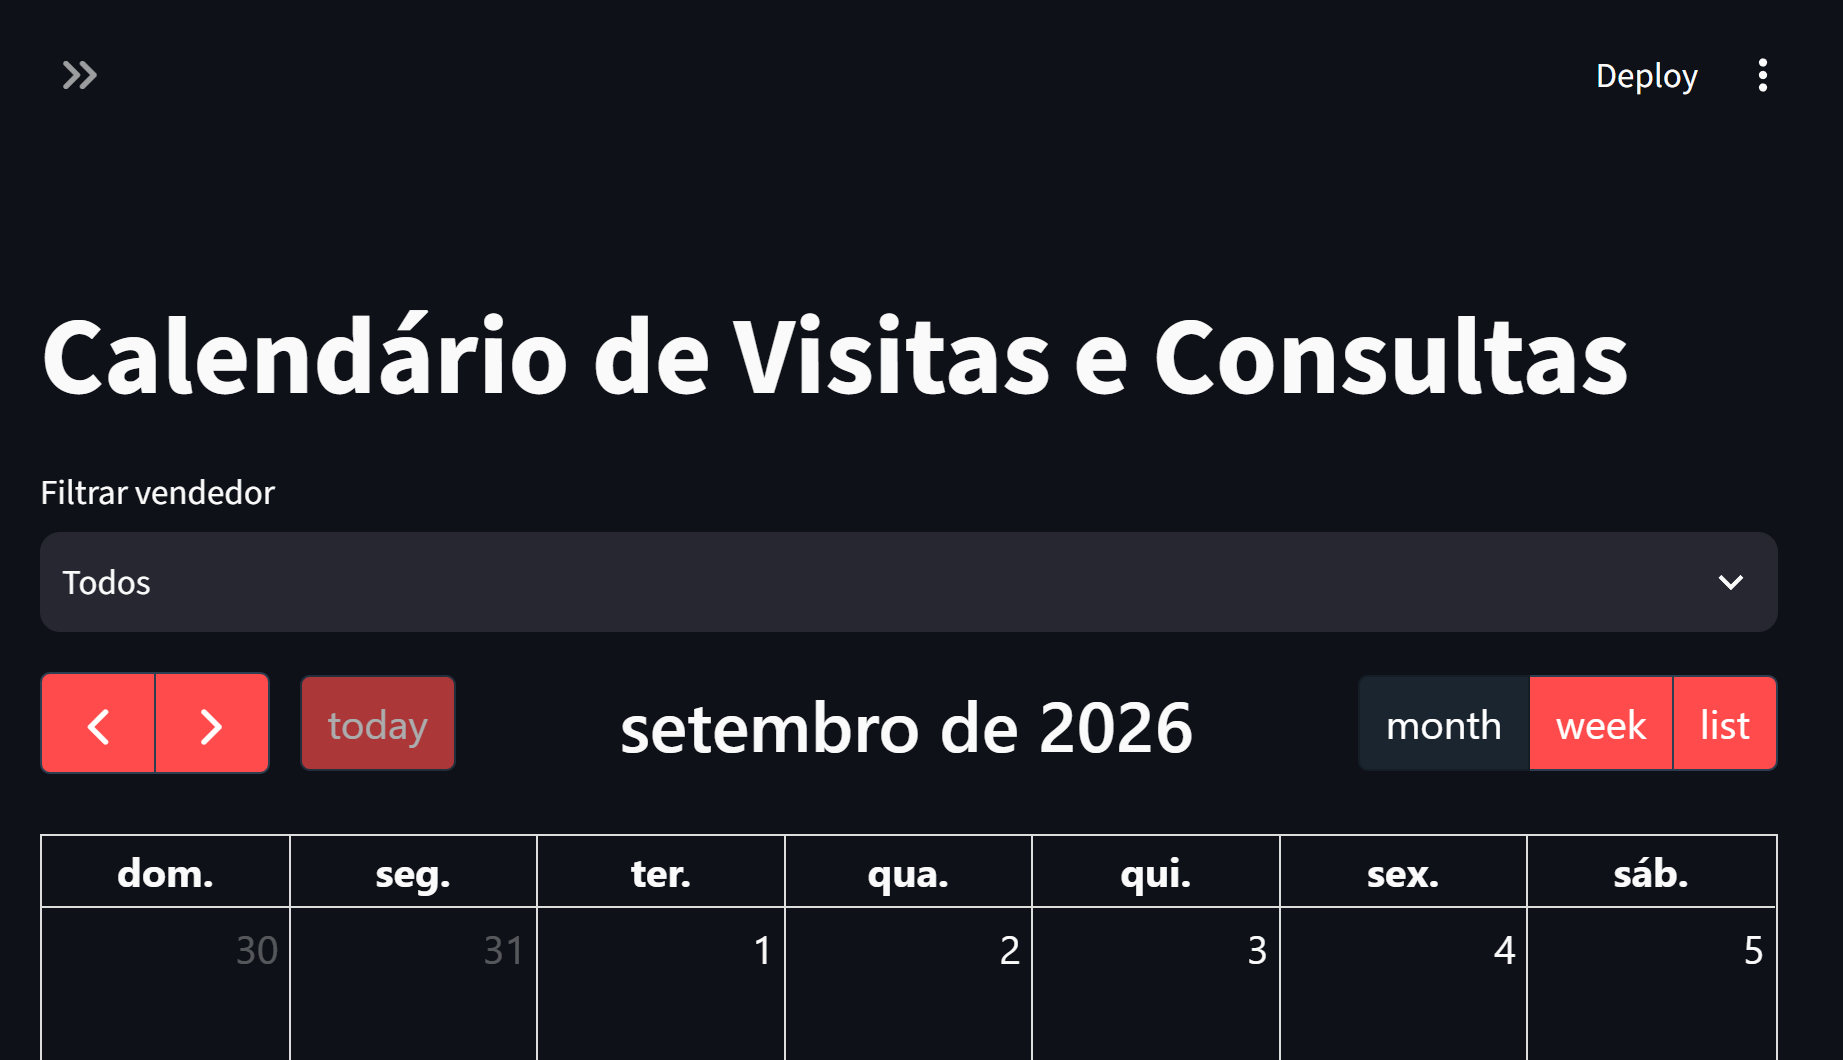

07_relatorios.png


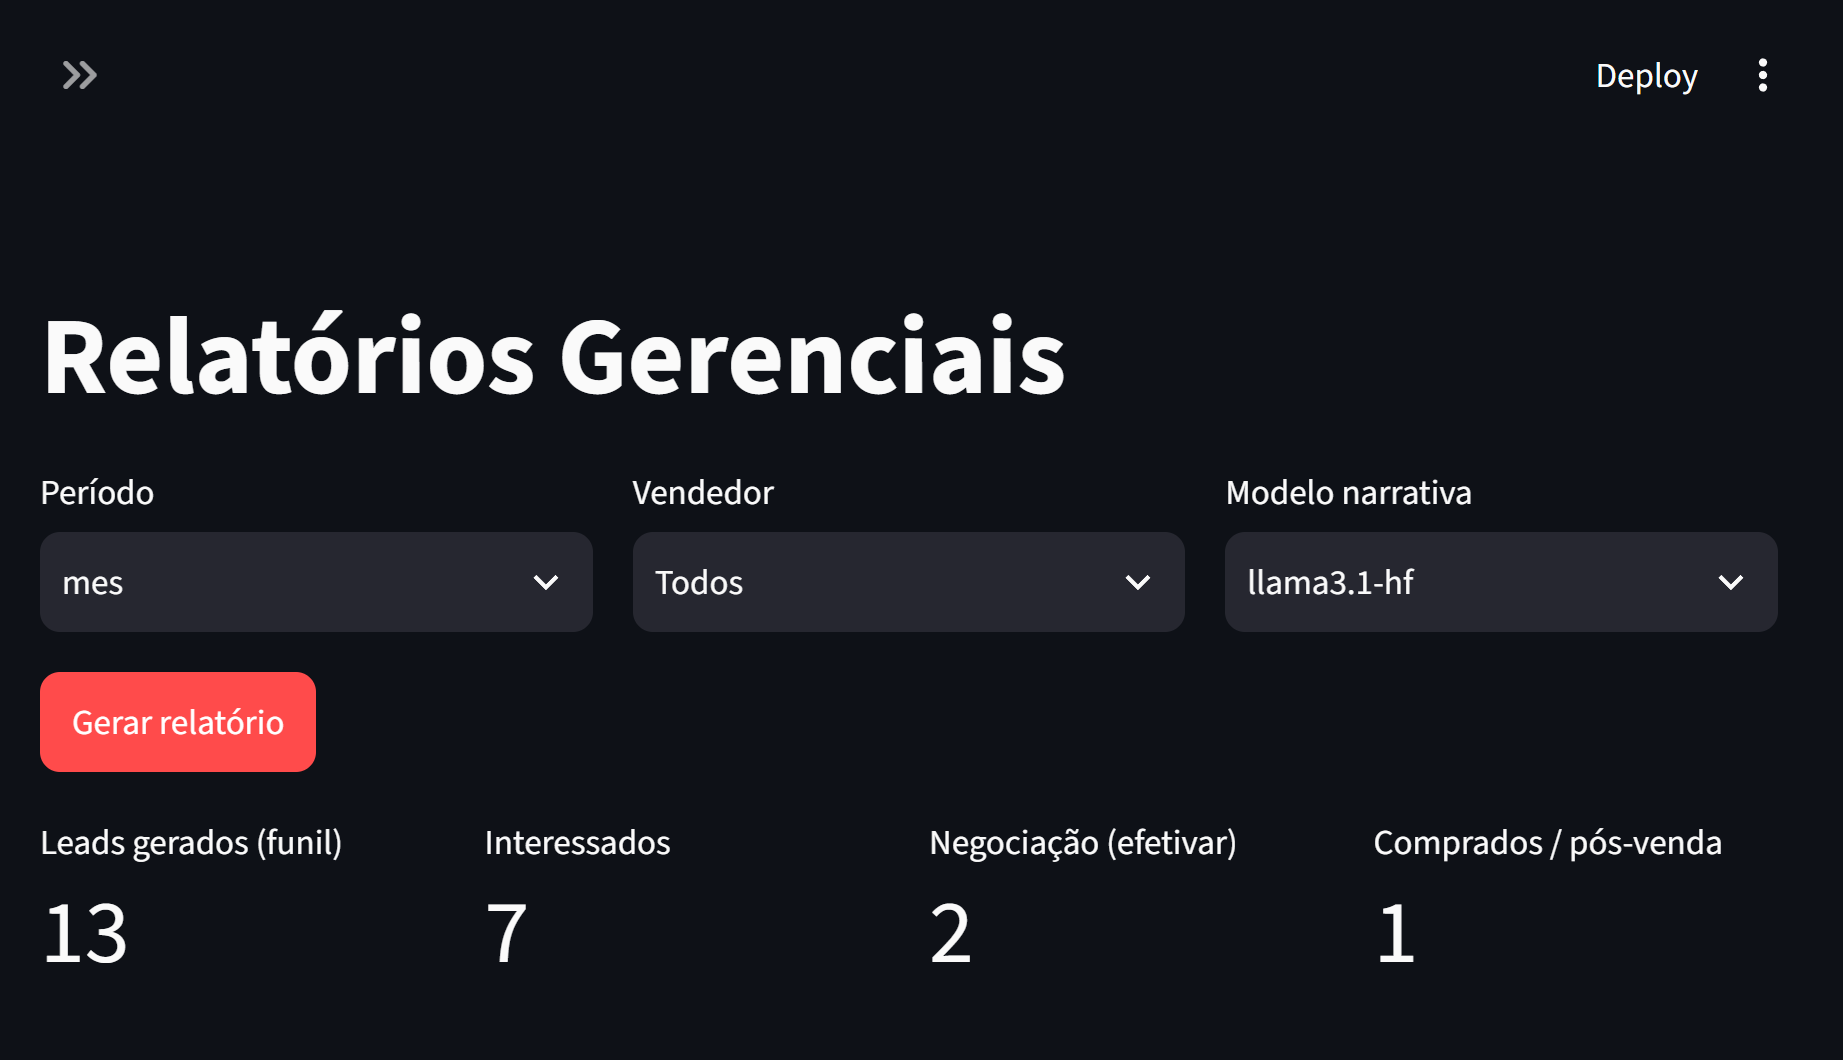

home_pitch.png


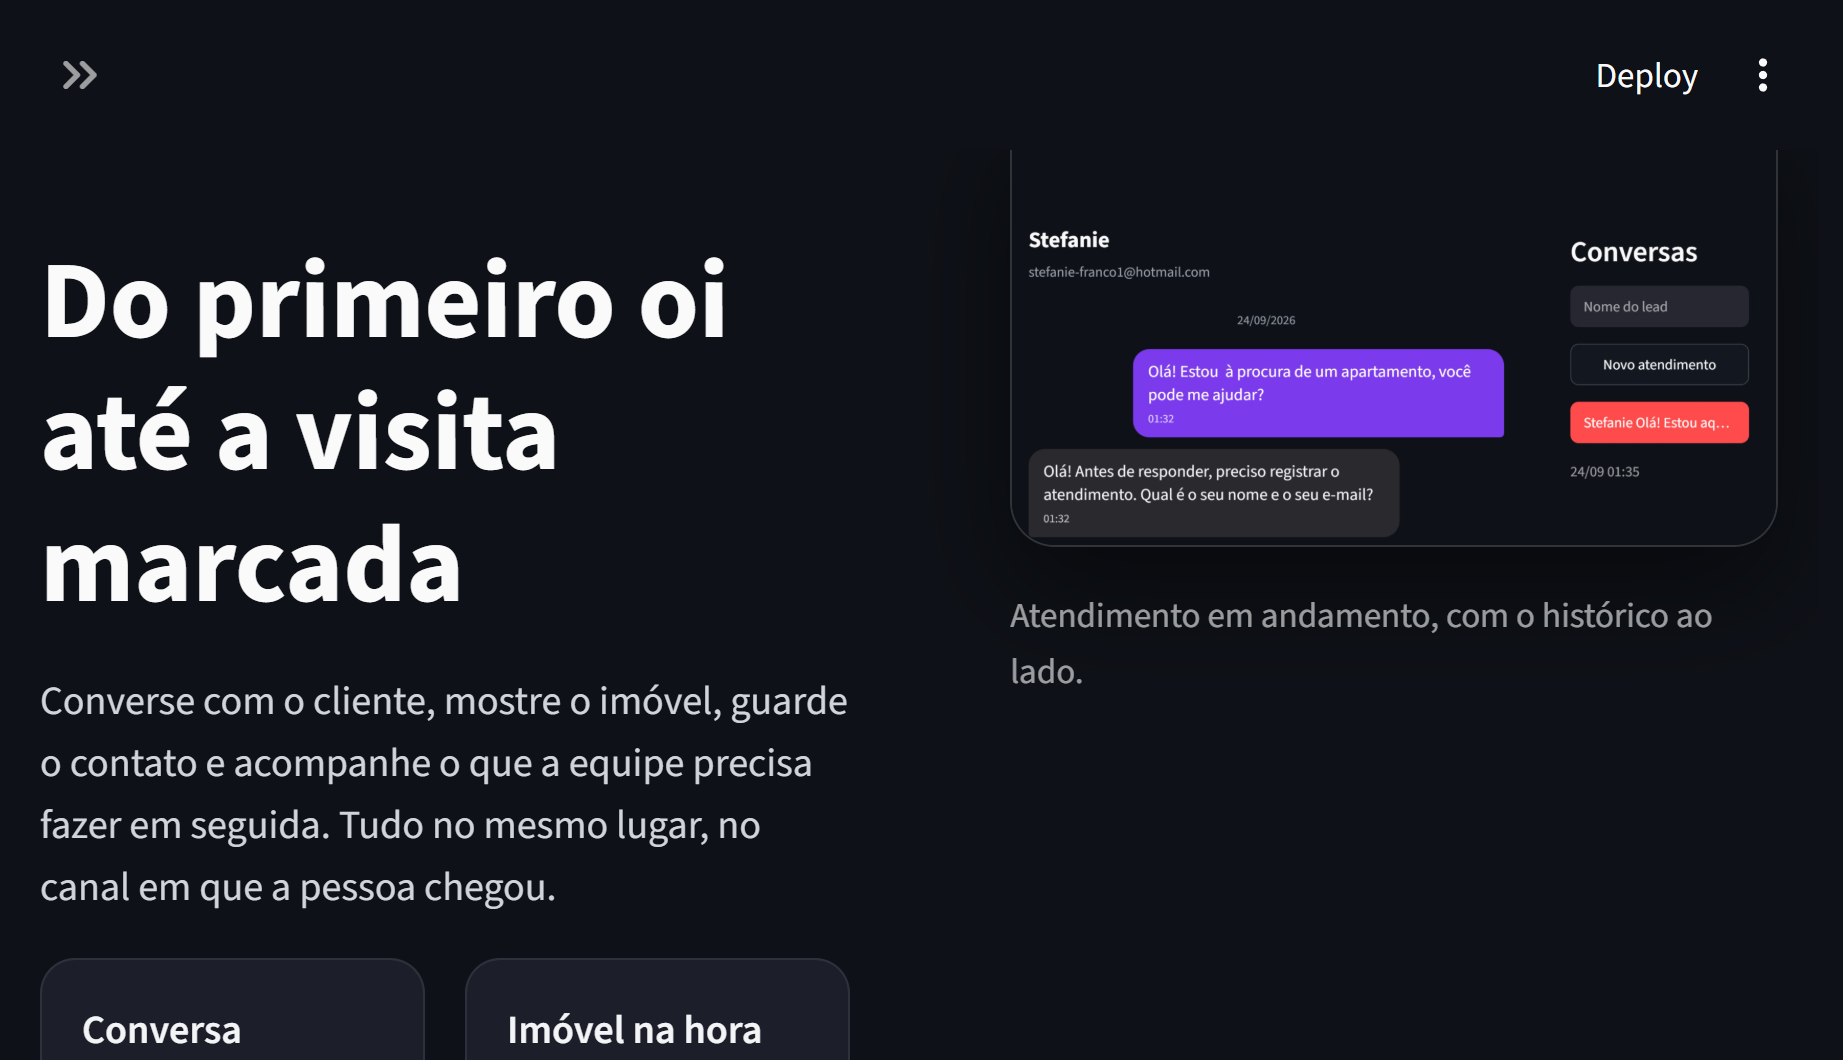

In [8]:
from IPython.display import Image, display
from pathlib import Path

shots = sorted((ROOT / "assets" / "screenshots").glob("*.png"))
if not shots:
    print("Nenhum PNG em assets/screenshots — adicione os prints da demo.")
else:
    for p in shots:
        print(p.name)
        display(Image(filename=str(p)))